# 09j — MOL00583 libera in acqua: confronto con lo stato legato
**PEARL · Windows CUDA · kernel Python (PEARL GPU)**

Prima simulazione indipendente del ligando in acqua, **nello stesso microstato neutro di 09h**. È un confronto conformazionale condizionato alla chimica scelta, non una verifica del microstato dominante a pH 7,4 e non un calcolo di ΔG di binding. Il controllo chimico ha confermato formula C22H23N5O3, carica formale 0 e 53 atomi; l'enumerazione RDKit ha prodotto 21 tautomeri candidati, senza assegnare pKa o popolazioni. Le alternative non sono automaticamente selezionate o parametrizzate.

I parametri OpenFF/AM1-BCC provengono esattamente da 09h. Non servono OpenFF, RDKit o AmberTools sul PC per eseguire questo notebook. Il confronto libero/legato usa RMSD **con fit del ligando**, estensione e idratazione: non confondere questo RMSD conformazionale con quello dopo fit su EGFR usato in 09h.

**Default sicuro:** RUN_MD=False. Prima eseguire il preflight; poi RUN_MD=True e FAST_TEST_MODE=True per 50 ps, una replica. Solo dopo il test impostare FAST_TEST_MODE=False: 3 repliche da 10 ns ciascuna, sequenziali. Sono durate esplorative, non una garanzia di convergenza. Nessun calcolo viene avviato senza cambiare RUN_MD. Non eseguire questo notebook insieme a un altro lungo calcolo sulla stessa GPU.

In [3]:
from pathlib import Path
import json,hashlib,time,random,sys,platform
from datetime import datetime,timezone
import numpy as np
import pandas as pd
import openmm as mm
from openmm import app,unit
import mdtraj as mt
import matplotlib.pyplot as plt

PEARL_ROOT=Path(r'C:\Users\Roberto\PEARL')
ASSETS=PEARL_ROOT/'inputs'
BOUND=PEARL_ROOT/'outputs/pipeline_5_pharmacophore_09h_mol00583_md/20260912T174721_843455Z_seed20260912'
OUTPUT_BASE=PEARL_ROOT/'outputs/pipeline_5_09j_free_ligand'
RUN_MD=True
FAST_TEST_MODE=True
PLATFORM='CUDA'
PLATFORM_PROPERTIES={'DeviceIndex':'0','Precision':'mixed'}
SEEDS=[20260921] if FAST_TEST_MODE else [20260921,20260922,20260923]
NVT_PS=10.0 if FAST_TEST_MODE else 100.0
NPT_PS=10.0 if FAST_TEST_MODE else 200.0
PRODUCTION_PS=50.0 if FAST_TEST_MODE else 10000.0
FRAME_PS=1.0 if FAST_TEST_MODE else 10.0
DT_PS=0.002
TEMPERATURE_K=300.0
PRESSURE_BAR=1.0
PADDING_NM=1.2
SALT_M=0.15
DISCARD_FRACTION=0.2
SAVE_FULL_DCD=False # ligand DCD always saved; hydration measured during simulation

def require(ok,msg):
    if not ok:raise RuntimeError(msg)
def dump(p,o):Path(p).write_text(json.dumps(o,indent=2,default=str),encoding='utf-8')
def sha(p):
    h=hashlib.sha256()
    with Path(p).open('rb') as f:
        for b in iter(lambda:f.read(1024*1024),b''):h.update(b)
    return h.hexdigest()
def steps(ps):
    value=round(ps/DT_PS)
    require(value>0 and abs(value*DT_PS-ps)<1e-9,'Durata non multipla di 2 fs.')
    return value

manifest=json.loads((ASSETS/'assets_sha256.json').read_text())
for name,digest in manifest.items():require(sha(ASSETS/name)==digest,f'Input corrotto: {name}')
for name in ['trajectories/production_solute.dcd','structures/solute_reference_09f.pdb','09h_summary.json']:
    require((BOUND/name).is_file(),f'Input 09h assente: {BOUND/name}')
source_summary=json.loads((BOUND/'09h_summary.json').read_text())
require(source_summary['mode']=='production' and source_summary['technical_qc_pass'] and source_summary['production_ps']==1000,
        'Sorgente 09h deve essere il run verificato da 1 ns.')
audit=json.loads((ASSETS/'chemical_audit.json').read_text())
print('Microstato:',audit['smiles'],'| carica:',audit['formal_charge'])
print('Questo protocollo NON determina pKa o predominanza a pH 7.4.')
print('Repliche:',len(SEEDS),'| produzione per replica:',PRODUCTION_PS,'ps')
require(RUN_MD,'Preflight completato. Impostare RUN_MD=True per il test.')

Microstato: COc1ccc(NC(C)=O)cc1NC(=O)c1cnc(Nc2ccc(C)c(C)c2)nc1 | carica: 0
Questo protocollo NON determina pKa o predominanza a pH 7.4.
Repliche: 1 | produzione per replica: 50.0 ps


## 1. Preparazione del ligando libero
i parte dalla geometria di MOL00583 proveniente da 09f e già utilizzata in 09h, successivamente traslata all'origine per la simulazione del ligando libero. Le analisi A24–A26b hanno successivamente mostrato che la posa 09e/09f propagata a 09h è esterna alla nativa interfaccia EGF–EGFR e che la traiettoria 09h non raggiunge tale interfaccia nei 400 frame production analizzati dopo lo scarto iniziale. Questa informazione limita l'interpretazione dello stato legato di riferimento, ma non invalida la simulazione 09j del ligando libero in acqua: 09j descrive il comportamento conformazionale e l'idratazione di MOL00583 nel microstato neutro adottato, a partire da quella specifica geometria iniziale, e non verifica il binding al sito EGF. Le repliche condividono la stessa geometria iniziale ma hanno semi distinti per solvente e velocità: sono repliche stocastiche, non campionamenti di microstati diversi. La dipendenza dalla conformazione iniziale deve essere valutata e non assunta trascurabile.

TIP3P, NaCl 0,15 M aggiuntivo e neutralizzazione, PME 1 nm e vincoli H-bonds. Nessuna restrizione posizionale. Prima della solvation si confrontano le cariche, sigma ed epsilon con 09h.

In [4]:
ligpdb=app.PDBFile(str(ASSETS/'MOL00583_initial.pdb'))
ff=app.ForceField(str(ASSETS/'MOL00583_09h_parameters.xml'),'amber14/tip3p.xml')
dry=ff.createSystem(ligpdb.topology,nonbondedMethod=app.NoCutoff,constraints=app.HBonds)
nbf=next(f for f in dry.getForces() if isinstance(f,mm.NonbondedForce))
observed=[]
for i in range(dry.getNumParticles()):
    q,s,e=nbf.getParticleParameters(i)
    observed.append([q.value_in_unit(unit.elementary_charge),s.value_in_unit(unit.nanometer),e.value_in_unit(unit.kilojoule_per_mole)])
require(np.allclose(observed,json.loads((ASSETS/'ligand_nb_reference.json').read_text()),atol=1e-8,rtol=0),
        'Parametri ligando diversi da 09h.')
nlig=ligpdb.topology.getNumAtoms()
ligtop=mt.Topology.from_openmm(ligpdb.topology)
heavy=np.array([a.index for a in ligtop.atoms if a.element.symbol!='H'])
ligbonds=np.array([[a.index,b.index] for a,b in ligtop.bonds],dtype=int)
RUN=OUTPUT_BASE/datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
RUN.mkdir(parents=True,exist_ok=False)
config={k:v for k,v in list(globals().items()) if k.isupper() and isinstance(v,(str,float,int,bool,list,dict,Path))}
provenance={'status':'prepared','config':config,'chemistry':audit,'OpenMM':mm.__version__,
 'python':sys.version,'host':platform.platform(),'source_09h':source_summary,'assets_hashes':manifest,
 'bound_trajectory_sha256':sha(BOUND/'trajectories/production_solute.dcd'),
 'purpose':'free_ligand_MD_same_neutral_microstate','experimentally_validated':False}
dump(RUN/'provenance.json',provenance)
print('Output:',RUN)

Output: C:\Users\Roberto\PEARL\outputs\pipeline_5_09j_free_ligand\20260914T085135_785664Z


## 2. MD per replica: minimizzazione → NVT → NPT → produzione
I file di ogni replica sono separati. Il tempo in produzione parte da zero. Il log mostra avanzamento, throughput misurato comprensivo delle letture per l'idratazione e stima residua per la replica corrente.

Il numero di acque entro 3,5 Å è un conteggio geometrico di ossigeni d'acqua vicini ad almeno un atomo pesante del ligando, usando il minimo d'immagine. Non equivale a legami H o a energia libera di idratazione. Le celle periodiche devono restare ortorombiche; il notebook lo controlla.

In [5]:
def save_state(sim,path):
    st=sim.context.getState(getPositions=True,getVelocities=True,getEnergy=True,getParameters=True)
    require(np.isfinite(st.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)),'Energia non finita.')
    require(np.isfinite(st.getPositions(asNumpy=True).value_in_unit(unit.nanometer)).all(),'Coordinate non finite.')
    path.with_suffix('.xml').write_text(mm.XmlSerializer.serialize(st))
    sim.saveCheckpoint(str(path.with_suffix('.chk')))
    return st

def reporter(path):
    return app.StateDataReporter(str(path),steps(FRAME_PS),step=True,time=True,potentialEnergy=True,
       temperature=True,volume=True,density=True,speed=True,separator=',')

replica_dirs=[]
provenance['status']='running';dump(RUN/'provenance.json',provenance)
try:
    for rep,seed in enumerate(SEEDS,1):
        folder=RUN/f'replica_{rep:02d}_seed{seed}';folder.mkdir();replica_dirs.append(folder)
        random.seed(seed);np.random.seed(seed)
        model=app.Modeller(ligpdb.topology,ligpdb.positions)
        model.addSolvent(ff,model='tip3p',padding=PADDING_NM*unit.nanometer,ionicStrength=SALT_M*unit.molar,
                         neutralize=True,positiveIon='Na+',negativeIon='Cl-')
        system=ff.createSystem(model.topology,nonbondedMethod=app.PME,nonbondedCutoff=1*unit.nanometer,
                              constraints=app.HBonds,rigidWater=True)
        nbforce=next(f for f in system.getForces() if isinstance(f,mm.NonbondedForce))
        net=sum(nbforce.getParticleParameters(i)[0].value_in_unit(unit.elementary_charge) for i in range(system.getNumParticles()))
        require(abs(net)<1e-3,'Sistema non neutro.')
        barostat=mm.MonteCarloBarostat(PRESSURE_BAR*unit.bar,TEMPERATURE_K*unit.kelvin,25)
        barostat.setRandomNumberSeed(seed+100);barostat.setFrequency(0);system.addForce(barostat)
        integ=mm.LangevinMiddleIntegrator(TEMPERATURE_K*unit.kelvin,1/unit.picosecond,DT_PS*unit.picosecond)
        integ.setRandomNumberSeed(seed);integ.setConstraintTolerance(1e-6)
        print(f'Replica {rep}/{len(SEEDS)}: {system.getNumParticles()} particelle, creazione contesto...',flush=True)
        sim=app.Simulation(model.topology,system,integ,mm.Platform.getPlatformByName(PLATFORM),PLATFORM_PROPERTIES)
        with (folder/'solvated.pdb').open('w') as f:app.PDBFile.writeFile(model.topology,model.positions,f,keepIds=True)
        sim.context.setPositions(model.positions)
        print('Minimizzazione...',flush=True);sim.minimizeEnergy(maxIterations=5000)
        save_state(sim,folder/'minimized')
        sim.context.setVelocitiesToTemperature(TEMPERATURE_K*unit.kelvin,seed)
        sim.reporters=[reporter(folder/'nvt.csv')]
        print('NVT...',flush=True);sim.step(steps(NVT_PS));sim.reporters=[]
        barostat.setFrequency(25);sim.context.reinitialize(preserveState=True)
        sim.reporters=[reporter(folder/'npt.csv')]
        print('NPT...',flush=True);sim.step(steps(NPT_PS));sim.reporters=[]
        save_state(sim,folder/'equilibrated')
        sim.context.setTime(0*unit.picosecond);sim.currentStep=0
        (folder/'production_system.xml').write_text(mm.XmlSerializer.serialize(system))
        (folder/'production_integrator.xml').write_text(mm.XmlSerializer.serialize(integ))
        fulltop=mt.Topology.from_openmm(model.topology)
        waterO=np.array([a.index for a in fulltop.atoms if a.residue.is_water and a.element.symbol=='O'])
        require(len(waterO)>0,'Acque assenti.')
        sim.reporters=[app.DCDReporter(str(folder/'ligand.dcd'),steps(FRAME_PS),atomSubset=list(range(nlig)),
                                      enforcePeriodicBox=False),reporter(folder/'production.csv'),
                       app.CheckpointReporter(str(folder/'latest.chk'),steps(FRAME_PS)*10)]
        if SAVE_FULL_DCD:sim.reporters.append(app.DCDReporter(str(folder/'full.dcd'),steps(FRAME_PS),enforcePeriodicBox=False))
        require(steps(PRODUCTION_PS)%steps(FRAME_PS)==0,'Produzione non multipla del frame interval.')
        nframes=steps(PRODUCTION_PS)//steps(FRAME_PS);hydration=[];t0=time.perf_counter()
        for frame in range(1,nframes+1):
            sim.step(steps(FRAME_PS))
            st=sim.context.getState(getPositions=True)
            xyz=st.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
            box=st.getPeriodicBoxVectors(asNumpy=True).value_in_unit(unit.nanometer)
            require(np.allclose(box,np.diag(np.diag(box)),atol=1e-6),'Box non ortorombico: adattare minimo immagine.')
            delta=xyz[waterO,None,:]-xyz[heavy][None,:,:]
            lengths=np.diag(box);delta-=lengths*np.round(delta/lengths)
            nwater=int((np.linalg.norm(delta,axis=2).min(axis=1)<=0.35).sum())
            hydration.append({'time_ps':frame*FRAME_PS,'nearby_water_oxygens_3p5A':nwater})
            if frame%max(1,nframes//20)==0 or frame==nframes:
                elapsed=time.perf_counter()-t0;speed=(frame*FRAME_PS/1000)*86400/elapsed
                pd.DataFrame(hydration).to_csv(folder/'hydration.csv',index=False)
                print(f'Replica {rep}: {100*frame/nframes:.0f}% | {frame*FRAME_PS:.0f} ps | {speed:.1f} ns/giorno | '
                      f'restano circa {(nframes-frame)/frame*elapsed/60:.1f} min',flush=True)
        save_state(sim,folder/'final');sim.reporters=[]
        dump(folder/'completed.json',{'seed':seed,'production_ps':PRODUCTION_PS,'frames':nframes,'status':'completed'})
        del sim,integ
except Exception as exc:
    provenance.update(status='failed',error=repr(exc));dump(RUN/'provenance.json',provenance)
    raise

Replica 1/1: 2556 particelle, creazione contesto...
Minimizzazione...
NVT...
NPT...
Replica 1: 4% | 2 ps | 897.6 ns/giorno | restano circa 0.1 min
Replica 1: 8% | 4 ps | 928.0 ns/giorno | restano circa 0.1 min
Replica 1: 12% | 6 ps | 939.3 ns/giorno | restano circa 0.1 min
Replica 1: 16% | 8 ps | 968.3 ns/giorno | restano circa 0.1 min
Replica 1: 20% | 10 ps | 970.8 ns/giorno | restano circa 0.1 min
Replica 1: 24% | 12 ps | 983.7 ns/giorno | restano circa 0.1 min
Replica 1: 28% | 14 ps | 985.9 ns/giorno | restano circa 0.1 min
Replica 1: 32% | 16 ps | 984.0 ns/giorno | restano circa 0.0 min
Replica 1: 36% | 18 ps | 980.1 ns/giorno | restano circa 0.0 min
Replica 1: 40% | 20 ps | 975.8 ns/giorno | restano circa 0.0 min
Replica 1: 44% | 22 ps | 973.3 ns/giorno | restano circa 0.0 min
Replica 1: 48% | 24 ps | 972.0 ns/giorno | restano circa 0.0 min
Replica 1: 52% | 26 ps | 978.5 ns/giorno | restano circa 0.0 min
Replica 1: 56% | 28 ps | 979.8 ns/giorno | restano circa 0.0 min
Replica 1: 6

## 3. Confronto libero/legato e QC
RMSD conformazionale: fit indipendente degli atomi pesanti del ligando al riferimento iniziale, identico per le traiettorie libera e legata. Non misura la ritenzione nel sito. Il raggio geometrico degli atomi pesanti descrive l'estensione, senza pesi di massa. I frame non sono corretti per simmetria.

Si scarta il primo 20% di ciascuna produzione. La traiettoria 09h usata come riferimento dello stato precedentemente definito “legato” è una singola traiettoria da 1 ns, mentre lo stato libero comprende repliche fino a 10 ns: le finestre temporali sono quindi diverse e il confronto è esplorativo. A26b ha mostrato che la traiettoria 09h rimane esterna alla nativa interfaccia EGF–EGFR; di conseguenza, in questo notebook il termine “bound/legato” identifica esclusivamente la configurazione EGFR–MOL00583 simulata in 09h e non deve essere interpretato come stato legato al sito EGF. Le distribuzioni non misurano popolazioni convergenti, affinità o entropia di binding; nessun test statistico assume che i frame siano indipendenti.

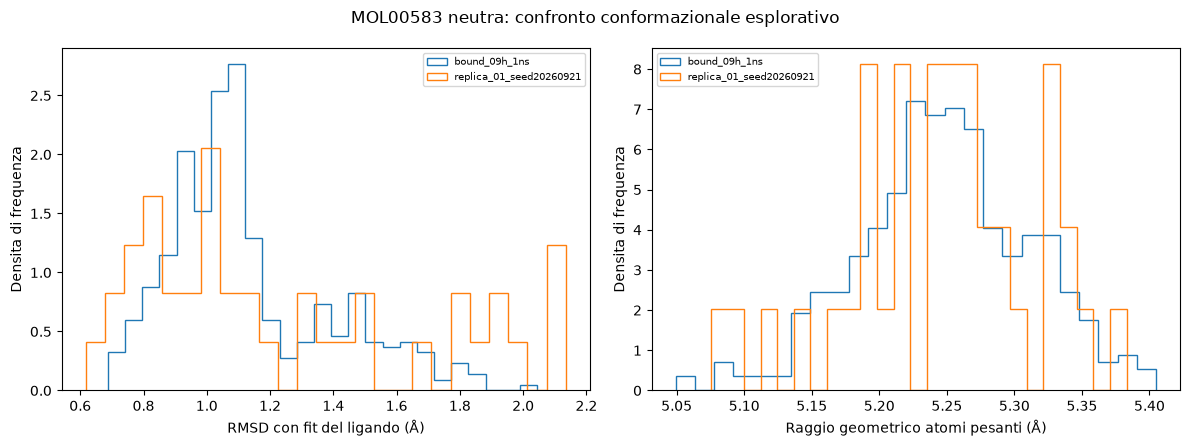

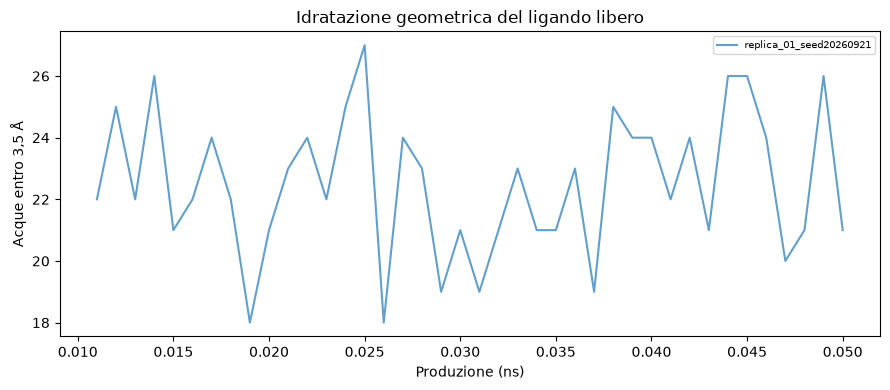

RMSD_conformation_A                                \
                                       mean       std       min       max   
series                                                                      
bound_09h_1ns                      1.129866  0.257227  0.687461  2.044164   
replica_01_seed20260921            1.238820  0.455760  0.617025  2.135000   

                        heavy_geometric_radius_A                                
                                            mean       std       min       max  
series                                                                          
bound_09h_1ns                           5.248666  0.063235  5.049312  5.404830  
replica_01_seed20260921                 5.245795  0.070041  5.075125  5.383027

,replica,mean_temperature_K,mean_density_g_mL,finite_log,temperature_OK,density_OK,QC_PASS
0,replica_01_seed20260921,299.474637,0.99643,True,True,True,True


{
  "candidate": "MOL00583",
  "mode": "smoke_test",
  "microstate": "neutral_same_as_09h",
  "protonation_populations_validated": false,
  "replicas": 1,
  "production_ps_per_replica": 50.0,
  "technical_qc_pass": true,
  "bound_source_ps": 1000,
  "interpretation": "Confronto conformazionale/idrazione a microstato fisso; non DeltaG o entropia di binding.",
  "experimentally_validated": false
}
Output: C:\Users\Roberto\PEARL\outputs\pipeline_5_09j_free_ligand\20260914T085135_785664Z


In [6]:
reference=mt.load(str(ASSETS/'MOL00583_initial.pdb'))
ligglobal=np.array(json.loads((ASSETS/'ligand_global_indices.json').read_text()),dtype=int)
bound_full=mt.load_dcd(str(BOUND/'trajectories/production_solute.dcd'),top=str(BOUND/'structures/solute_reference_09f.pdb'))
bound=bound_full.atom_slice(ligglobal)
require(bound.n_atoms==nlig,'Numero atomi ligando legato incompatibile.')
require([a.name for a in bound.topology.atoms]==[a.name for a in reference.topology.atoms],'Ordine atomico non coerente.')
def metrics(traj,frame_ps,label):
    require(np.isfinite(traj.xyz).all(),'Traiettoria non finita.')
    distances=mt.compute_distances(traj,ligbonds,periodic=False)
    require(distances.max()<0.30,'Legami spezzati/PBC: analisi non valida.')
    xyz=traj.xyz[:,heavy,:]
    center=xyz.mean(axis=1,keepdims=True)
    rg=np.sqrt(((xyz-center)**2).sum(axis=2).mean(axis=1))*10
    rmsd=mt.rmsd(traj,reference,atom_indices=heavy,ref_atom_indices=heavy)*10
    result=pd.DataFrame({'time_ps':(np.arange(traj.n_frames)+1)*frame_ps,'RMSD_conformation_A':rmsd,
                         'heavy_geometric_radius_A':rg,'series':label})
    result['included']=np.arange(traj.n_frames)>=int(traj.n_frames*DISCARD_FRACTION)
    return result
all_metrics=[metrics(bound,2.0,'bound_09h_1ns')];qc_rows=[]
for folder in replica_dirs:
    traj=mt.load_dcd(str(folder/'ligand.dcd'),top=ligtop)
    require(traj.n_frames==round(PRODUCTION_PS/FRAME_PS),'Traiettoria incompleta.')
    table=metrics(traj,FRAME_PS,folder.name);table.to_csv(folder/'conformation.csv',index=False)
    all_metrics.append(table)
    log=pd.read_csv(folder/'production.csv')
    temp=log[next(c for c in log if 'Temperature' in c)].to_numpy(float)
    density=log[next(c for c in log if 'Density' in c)].to_numpy(float)
    row={'replica':folder.name,'mean_temperature_K':temp.mean(),'mean_density_g_mL':density.mean(),
         'finite_log':bool(np.isfinite(temp).all() and np.isfinite(density).all()),
         'temperature_OK':bool(abs(temp.mean()-TEMPERATURE_K)<5),'density_OK':bool(0.95<density.mean()<1.05)}
    row['QC_PASS']=row['finite_log'] and row['temperature_OK'] and row['density_OK'];qc_rows.append(row)
combined=pd.concat(all_metrics,ignore_index=True);combined.to_csv(RUN/'free_bound_metrics.csv',index=False)
qc=pd.DataFrame(qc_rows);qc.to_csv(RUN/'09j_QC.csv',index=False)
selected=combined[combined.included]
stats=selected.groupby('series')[['RMSD_conformation_A','heavy_geometric_radius_A']].agg(['mean','std','min','max'])
stats.to_csv(RUN/'conformation_summary.csv')
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
for label,data in selected.groupby('series'):
    axes[0].hist(data.RMSD_conformation_A,bins=25,density=True,histtype='step',label=label)
    axes[1].hist(data.heavy_geometric_radius_A,bins=25,density=True,histtype='step',label=label)
axes[0].set(xlabel='RMSD con fit del ligando (Å)',ylabel='Densita di frequenza')
axes[1].set(xlabel='Raggio geometrico atomi pesanti (Å)',ylabel='Densita di frequenza')
axes[0].legend(fontsize=7);axes[1].legend(fontsize=7)
fig.suptitle('MOL00583 neutra: confronto conformazionale esplorativo');fig.tight_layout()
fig.savefig(RUN/'free_bound_conformation.png',dpi=220);plt.show()
fig,ax=plt.subplots(figsize=(9,4))
hydration_summary=[]
for folder in replica_dirs:
    h=pd.read_csv(folder/'hydration.csv');h=h.iloc[int(len(h)*DISCARD_FRACTION):]
    ax.plot(h.time_ps/1000,h.nearby_water_oxygens_3p5A,label=folder.name,alpha=0.7)
    hydration_summary.append({'replica':folder.name,'mean_nearby_water_oxygens':h.nearby_water_oxygens_3p5A.mean()})
ax.set(xlabel='Produzione (ns)',ylabel='Acque entro 3,5 Å',title='Idratazione geometrica del ligando libero')
ax.legend(fontsize=7);fig.tight_layout();fig.savefig(RUN/'free_hydration.png',dpi=220);plt.show()
pd.DataFrame(hydration_summary).to_csv(RUN/'hydration_summary.csv',index=False)
result={'candidate':'MOL00583','mode':'smoke_test' if FAST_TEST_MODE else 'exploratory_production',
 'microstate':'neutral_same_as_09h','protonation_populations_validated':False,
 'replicas':len(SEEDS),'production_ps_per_replica':PRODUCTION_PS,'technical_qc_pass':bool(qc.QC_PASS.all()),
 'bound_source_ps':1000,'interpretation':'Confronto conformazionale/idrazione a microstato fisso; non DeltaG o entropia di binding.',
 'experimentally_validated':False}
dump(RUN/'09j_summary.json',result)
provenance.update(status='completed',summary=result);dump(RUN/'provenance.json',provenance)
display(stats);display(qc);print(json.dumps(result,indent=2));print('Output:',RUN)

## Cosa resta da fare dopo questo notebook

09j affronta lo stato libero **a chimica fissa**. Non conclude l'approfondimento termodinamico del verbale. Servono ancora valutazione quantitativa dei microstati/pKa (le 21 forme enumerate non hanno uguale plausibilità o popolazione), eventuale parametrizzazione di stati alternativi, campionamento/repliche del complesso e scelta motivata di un protocollo di energia libera. Non sottrarre le energie totali del box del ligando e del box del complesso.

Nessun resume automatico: i checkpoint sono per eventuale ripartenza esperta nello stesso ambiente Windows/CUDA. Non rilanciare soltanto la cella MD su cartelle esistenti; riavviare dall'inizio crea una nuova cartella.

Fonti metodologiche: [OpenMM](https://docs.openmm.org/latest/userguide/application/02_running_sims.html), [OpenFF: microstati e tautomeri nella preparazione](https://openforcefield.org/community/news/general/introducing-openforcefield-1.0/). Il controllo RDKit è un'enumerazione topologica, non un predittore di pKa.